In [34]:
# Carga de librerías 

import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [35]:
# Carga de datos y carga del pipelin 

import joblib
df = pd.read_csv("../data/raw/clinical_trial_data.csv")
model_pipeline =joblib.load("../src/models/clinical_oracle_pipeline.pkl")

In [36]:
# Preparación de datos para trabajar solo con X_test 
X = df.drop(['Dropped_Out', 'Patient_ID'], axis = 1)
y = df['Dropped_Out']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify= y)


In [37]:
# Acceso al preprocesador 
preprocessor = model_pipeline.named_steps['preprocessor']
classifier = model_pipeline.named_steps['classifier']

In [38]:
# Transformación de datos 
X_test_transformed = preprocessor.transform(X_test)

In [39]:
# Reconstrucción de nombres 
numeric_features = ['Age', 'BMI', 'Systolic_BP', 'Glucose_Level']
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['Gender', 'Treatment_Arm'])
feature_names = numeric_features + list(cat_features)

In [40]:
# Creación del explainer 
explainer = shap.Explainer(classifier, X_test_transformed, feature_names=feature_names)
shap_values = explainer(X_test_transformed)

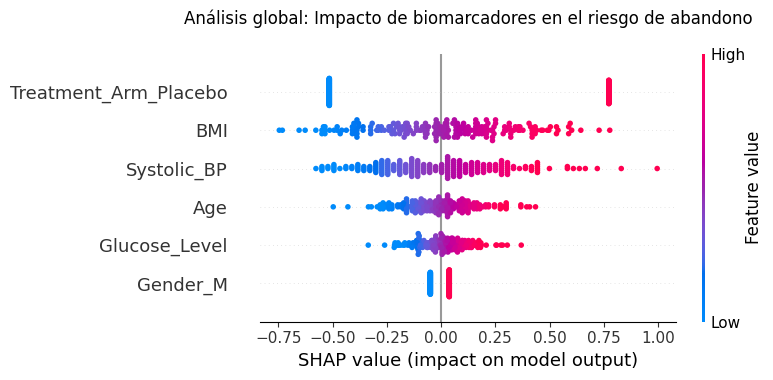

In [41]:
# Generación de gráfico 
plt.figure(figsize = (15,5))
shap.plots.beeswarm(shap_values, show= False)
plt.title("Análisis global: Impacto de biomarcadores en el riesgo de abandono\n")
plt.tight_layout()
plt.show()

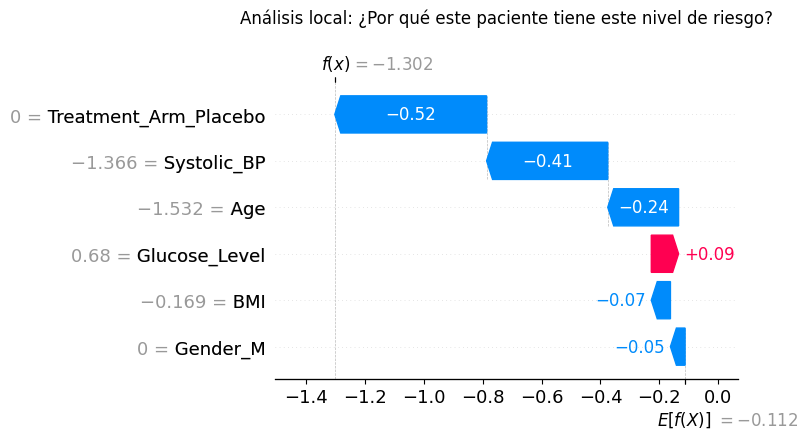

In [51]:
# Visualización de explicación local 

plt.figure(figsize = (15,5))
shap.plots.waterfall(shap_values[0], show=False) #Tomamos al paciente 1 
plt.title("Análisis local: ¿Por qué este paciente tiene este nivel de riesgo?\n")
plt.tight_layout()
plt.show()

# Conclusiones

En esta fase, se implementó la Teoría de Juegos de Shapley (SHAP) para auditar la lógica interna del algoritmo, transformando una "caja negra" predictiva en una herramienta de soporte de decisiones clínicas explicable y transparente.

1. Análisis global: Impacto sistémico de biomarcadores (SHAP Beeswarm Plot)

El análisis de importancia global validó que el modelo ha aprendido patrones biológicos y clínicos coherentes, alejándose de correlaciones:

* Identificador principal de riesgo: La variable Treatment_Arm_Placebo demostró ser el factor global de mayor impacto. El modelo aprendió correctamente que la privación del tratamiento activo es el principal disparador del abandono del ensayo.

* Validación de biomarcadores fisiológicos: Se confirmó una relación causal positiva entre los niveles altos de presión sistólica (Systolic_BP), el Índice de Masa Corporal elevado (BMI) y la edad avanzada (Age) frente al riesgo de abandono.

* Captura de no Linealidad: SHAP reveló visualmente que el nivel de glucosa (Glucose_Level) opera bajo un riesgo asimétrico, afectando la probabilidad de abandono principalmente en sus valores extremos, lo cual valida nuestro descubrimiento previo con la métrica de información mutua.

2. Análisis local: Explicabilidad individualizada (SHAP Waterfall Plot)

Se demostró la capacidad del modelo para realizar análisis a nivel paciente (Medicina Personalizada), una característica fundamental para la adopción tecnológica por parte del personal médico:

* El modelo es capaz de descomponer el riesgo predictivo exacto de un paciente individual, partiendo de la tasa de riesgo base de la cohorte (Expected Value) hasta llegar a la predicción final.

* En el caso del Paciente #0, la herramienta pudo cuantificar exactamente cómo la combinación de recibir el tratamiento activo y mantener una presión arterial controlada lograron suprimir el ligero aumento de riesgo que le provocaba su nivel de glucosa. Esto permite a los médicos no solo recibir una "alerta de abandono", sino comprender qué parámetro médico específico deben tratar para retener al paciente en el estudio.